# Capstone demo — Surface → SVI (+repair) → Local Vol → PDE + Diagnostics

This notebook is structured as a **showcase demo** for the capstone narrative and your extra engineering signal:
- SVI calibration per expiry
- SVI butterfly repair / fixing
- no-arbitrage diagnostics (smile + calendar + interpolation choice)
- local-vol diagnostics (Gatheral denominator / invalid masks)
- PDE convergence + stability diagnostics
- end-to-end repricing checks under local vol

> **Recommended talk track:** first show the *diagnostics-first* approach (why guardrails matter), then show the clean end-to-end pricing story.


## What this demo is designed to show off

1. **Pipeline completeness**: synthetic market quotes → implied surface → local vol → PDE pricing.
2. **Numerical judgment**: diagnostics are first-class outputs (not hidden internals).
3. **SVI engineering**: fit quality, butterfly proxy checks, and a repair path.
4. **No-arbitrage awareness**: smile checks, calendar checks, and no-arb interpolation option.
5. **PDE credibility**: convergence/stability plots and repricing consistency checks.

If you need a shorter presentation version, set the `RUN_*` flags in the config cell.


In [ ]:
# --- imports ---
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

# Core library objects
from option_pricing import (
    MarketData,
    OptionType,
    PricingInputs,
)
from option_pricing.data_generators.recipes import (
    generate_synthetic_surface_latent_noarb,
)

# PDE diagnostics plotting helpers
from option_pricing.diagnostics._pde_compare.plots import (
    plot_convergence as pde_plot_convergence,
)
from option_pricing.diagnostics._pde_compare.plots import (
    plot_error_vs_runtime as pde_plot_error_vs_runtime,
)
from option_pricing.diagnostics._pde_compare.plots import (
    plot_price_scatter as pde_plot_price_scatter,
)

# PDE diagnostics (constant-vol digital baseline)
from option_pricing.diagnostics.pde_vs_digital import run_demo_baseline_sweep

# Vol-surface diagnostics helpers
from option_pricing.diagnostics.vol_surface import localvol as vs_localvol
from option_pricing.diagnostics.vol_surface import plot as vs_plot
from option_pricing.diagnostics.vol_surface import report as vs_report
from option_pricing.diagnostics.vol_surface import svi as vs_svi
from option_pricing.diagnostics.vol_surface.pde_repricing import (
    localvol_pde_repricing_grid,
    localvol_pde_single_option_convergence_sweep,
)
from option_pricing.diagnostics.vol_surface.plot import plot_repricing_heatmap
from option_pricing.diagnostics.vol_surface.recipes import (
    build_svi_surface_with_fallback,
    default_svi_repair_candidates,
    gj_example51_check_table,
    gj_example51_comparison_table,
    run_explicit_svi_repair_demo,
)
from option_pricing.numerics.grids import SpacingPolicy

# Numerics config enums
from option_pricing.numerics.pde.domain import Coord
from option_pricing.numerics.pde.operators import AdvectionScheme
from option_pricing.pricers.pde.domain import BSDomainConfig, BSDomainPolicy
from option_pricing.types import DigitalSpec
from option_pricing.vol import LocalVolSurface, VolSurface, check_surface_noarb

# SVI diagnostics
from option_pricing.vol.svi.diagnostics import run_gj_example51_repair_sanity_check

In [ ]:

# --- demo controls / knobs ---
RUN_DUPIRE_VS_GATHERAL_COMPARE = True      # extra diagnostic (can be slower)
RUN_DIGITAL_PDE_BASELINE = True            # constant-vol digital convergence harness
RUN_LOCALVOL_REPRICING = True              # end-to-end local-vol PDE repricing
RUN_LOCALVOL_CONVERGENCE_SWEEP = True      # convergence on one local-vol vanilla

SEED = 7

# If True, the notebook will automatically tune/fallback the synthetic generator
# until the *latent truth* surface passes the library no-arb checker.
ENFORCE_ARB_FREE_LATENT_TRUTH = True

# Synthetic quote surface:
# - latent truth should be no-arb (checked and auto-tuned below)
# - observed quotes can still violate no-arb due to noise (that is intentional)
SYNTH_CFG = dict(
    spot=100.0,
    r=0.02,
    q=0.00,
    expiries = (0.10, 0.15, 0.20, 0.25, 0.33, 0.50, 0.75, 1.00, 1.25, 1.50, 2.00),
    x_grid=np.linspace(-0.30, 0.30, 31),
    # expiries=(0.10, 0.25, 0.50, 1.00, 1.50, 2.00),
    # x_grid=np.linspace(-0.30, 0.30, 31),

    # smoother SVI-like latent truth (much safer than defaults for short-tenor wings)
    model="svi",
    atm_level=0.20,
    atm_term_slope=0.045,
    atm_term_ref=0.50,
    b_level=0.030,
    b_term_slope=0.006,
    rho=-0.35,
    m_level=-0.015,
    m_decay=1.0,
    sigma_level=0.24,
    sigma_term_slope=0.02,

    # observed-noise controls (keep mild by default; explicit repair demo is shown later)
    noise_mode="relative",
    noise_level=0.006,
    noise_dist="normal",
    noise_smooth_window=3,
    outlier_prob=0.0,
    outlier_scale=4.0,
    missing_prob=0.0,
    seed=SEED,
)

# SVI calibration toggles
SVI_CALIB_NO_REPAIR = dict(
    robust_data_only=True,
    repair_butterfly=False,
    refit_after_repair=False,
)

SVI_CALIB_REPAIR = dict(
    robust_data_only=True,
    repair_butterfly=True,
    repair_method="line_search",
    repair_n_scan=101,      # more robust on narrow feasible regions
    repair_n_bisect=50,
    refit_after_repair=True,  # safer for demo stability (explicit refit discussion is optional)
)

# If the preferred repaired fit fails on some noisy dataset, try these in order.
SVI_CALIB_REPAIR_CANDIDATES = default_svi_repair_candidates(
    robust_data_only=True,
    include_robust_all_candidate=True,
)

# Local-vol diagnostics grids
LV_DIAG_EXPIRIES = np.linspace(0.12, 1.95, 10)
LV_DIAG_YGRID = np.linspace(-0.30, 0.30, 61)

# Shared strike grid for Dupire-vs-Gatheral and repricing checks
# SHARED_STRIKES = np.linspace(75.0, 130.0, 17)
# SHARED_EXPIRIES = np.array([0.25, 0.50, 1.00, 1.50, 2.00], dtype=float)
SHARED_STRIKES = np.linspace(75.0, 130.0, 31)
SHARED_EXPIRIES = np.array([0.10, 0.15, 0.20, 0.25, 0.33, 0.50, 0.75, 1.00, 1.25, 1.50, 2.00], dtype=float)


# PDE domain / solver defaults for local-vol vanilla pricing
LV_DOMAIN_CFG = BSDomainConfig(
    policy=BSDomainPolicy.LOG_NSIGMA,
    n_sigma=5.5,
    center="strike",
    spacing=SpacingPolicy.CLUSTERED,
    cluster_strength=2.5,
)

LV_PDE_SOLVER_CFG = dict(
    coord=Coord.LOG_S,
    domain_cfg=LV_DOMAIN_CFG,
    method="rannacher",
    advection=AdvectionScheme.CENTRAL,
)

# Grid sweep for local-vol convergence (single option)
LV_SWEEP_GRIDS = [(101, 201), (151, 301), (201, 401), (251, 501)]

# Table display controls (keep notebook readable by default)
SHOW_VERBOSE_TABLES = False
TABLE_PREVIEW_ROWS = 12


def show_table(title: str, df, *, max_rows: int | None = None):
    """Display a captioned table with truncation by default."""
    display(Markdown(f"### {title}"))
    if not isinstance(df, pd.DataFrame):
        df = pd.DataFrame(df)
    n = TABLE_PREVIEW_ROWS if max_rows is None else int(max_rows)
    if (not SHOW_VERBOSE_TABLES) and len(df) > n:
        display(df.head(n))
        display(Markdown(f"_Showing first {n} of {len(df)} rows. Set `SHOW_VERBOSE_TABLES = True` for full tables._"))
    else:
        display(df)


## 1) Build synthetic market quotes (with controlled noise / outliers)


In [ ]:
# --- Synthetic data build with latent no-arb validation / auto-tuning ---

syn = generate_synthetic_surface_latent_noarb(
    enforce=ENFORCE_ARB_FREE_LATENT_TRUTH,
    max_rounds=8,
    **SYNTH_CFG,
)

synthetic = syn.synthetic
surface_true_grid = syn.surface_true
noarb_true_grid = syn.noarb_true
rows_true = syn.rows_true
synth_cfg_used = syn.cfg_used
synth_tuning_log = syn.tuning_log

quotes_df = pd.DataFrame(
    {
        "T": synthetic.T,
        "x": synthetic.x,
        "K": synthetic.K,
        "F": synthetic.F,
        "iv_obs": synthetic.iv_obs,
        "iv_true": synthetic.iv_true,
    }
).sort_values(["T", "K"]).reset_index(drop=True)

quotes_df["y"] = np.log(quotes_df["K"] / quotes_df["F"])
quotes_df["w_obs"] = quotes_df["T"] * quotes_df["iv_obs"] ** 2
quotes_df["w_true"] = quotes_df["T"] * quotes_df["iv_true"] ** 2
quotes_df["iv_noise_bp"] = 1e4 * (quotes_df["iv_obs"] - quotes_df["iv_true"])

show_table("Latent-truth no-arb tuning log (auto-check)", synth_tuning_log, max_rows=10)

show_table(
    "Latent truth no-arb check (benchmark surface)",
    pd.DataFrame(
        [
            {
                "latent_truth_ok": bool(noarb_true_grid.ok),
                "message": str(noarb_true_grid.message),
                "calendar_ok": (
                    bool(noarb_true_grid.calendar_total_variance.ok)
                    if noarb_true_grid.calendar_total_variance.performed
                    else np.nan
                ),
                "calendar_max_violation": (
                    float(noarb_true_grid.calendar_total_variance.max_violation)
                    if noarb_true_grid.calendar_total_variance.performed
                    else np.nan
                ),
            }
        ]
    ),
)

show_table("Synthetic config actually used", pd.DataFrame([synth_cfg_used]), max_rows=50)

show_table("Quote sample", quotes_df, max_rows=12)

show_table(
    "Quote summary by expiry",
    quotes_df.groupby("T")
    .agg(
        n_quotes=("K", "size"),
        iv_obs_min=("iv_obs", "min"),
        iv_obs_max=("iv_obs", "max"),
        mean_abs_noise_bp=("iv_noise_bp", lambda s: float(np.mean(np.abs(s)))),
    )
    .reset_index(),
)

### Latent-truth no-arb tuning log (auto-check)

,round,model,ok,message,atm_level,atm_term_slope,b_level,b_term_slope,rho,m_level,sigma_level,sigma_term_slope
0,0,svi,True,"OK, mono_bad=0/11, butterfly_bad=0/11, calenda...",0.2,0.045,0.03,0.006,-0.35,-0.015,0.24,0.02


### Latent truth no-arb check (benchmark surface)

,latent_truth_ok,message,calendar_ok,calendar_max_violation
0,True,"OK, mono_bad=0/11, butterfly_bad=0/11, calenda...",True,0.0


### Synthetic config actually used

...

### Quote sample

,T,x,K,F,iv_obs,iv_true,y,w_obs,w_true,iv_noise_bp
0,0.1,-0.30,74.230134,100.2002,0.344667,0.344460,-0.30,0.011880,0.011865,2.075065
1,0.1,-0.28,75.729682,100.2002,0.334169,0.334152,-0.28,0.011167,0.011166,0.172675
2,0.1,-0.26,77.259523,100.2002,0.323206,0.323767,-0.26,0.010446,0.010482,-5.607538
3,0.1,-0.24,78.820269,100.2002,0.312315,0.313330,-0.24,0.009754,0.009818,-10.148127
4,0.1,-0.22,80.412544,100.2002,0.301459,0.302875,-0.22,0.009088,0.009173,-14.155813
5,0.1,-0.20,82.036985,100.2002,0.291634,0.292445,-0.20,0.008505,0.008552,-8.107591
6,0.1,-0.18,83.694242,100.2002,0.282326,0.282096,-0.18,0.007971,0.007958,2.305918
7,0.1,-0.16,85.384978,100.2002,0.272388,0.271894,-0.16,0.007420,0.007393,4.938431
8,0.1,-0.14,87.109869,100.2002,0.262044,0.261924,-0.14,0.006867,0.006860,1.191933
9,0.1,-0.12,88.869605,100.2002,0.251969,0.252283,-0.12,0.006349,0.006365,-3.142641


_Showing first 12 of 341 rows. Set `SHOW_VERBOSE_TABLES = True` for full tables._

### Quote summary by expiry

,T,n_quotes,iv_obs_min,iv_obs_max,mean_abs_noise_bp
0,0.10,31,0.197434,0.344667,7.107590
1,0.15,31,0.206079,0.308230,4.016473
2,0.20,31,0.210472,0.290812,5.220291
3,0.25,31,0.214289,0.281942,6.405934
4,0.33,31,0.218894,0.270295,5.318049
5,0.50,31,0.228127,0.262923,4.284382
6,0.75,31,0.239053,0.264918,7.891121
7,1.00,31,0.247678,0.265626,7.474144
8,1.25,31,0.254843,0.267848,7.927830
9,1.50,31,0.261446,0.273418,6.739342


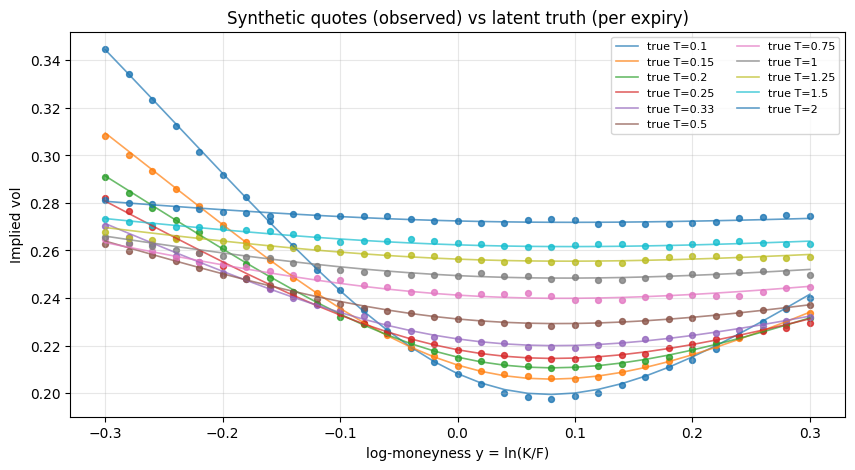

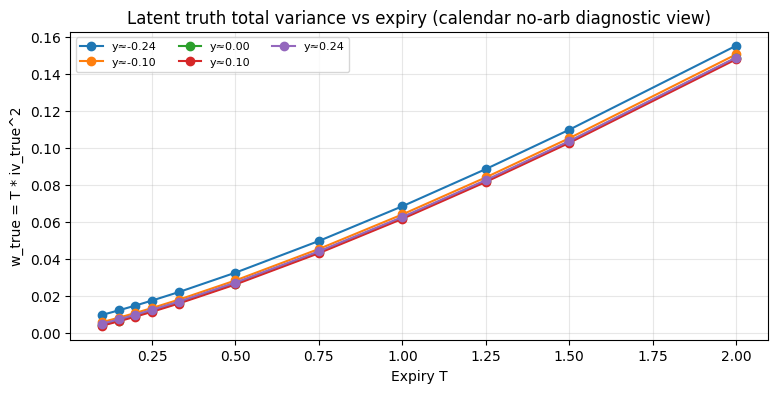

In [ ]:
# Visual check: observed vs true IV smile per expiry
fig, ax = plt.subplots(figsize=(10, 5))
for T, g in quotes_df.groupby("T", sort=True):
    ax.plot(g["y"], g["iv_true"], linewidth=1.2, alpha=0.7, label=f"true T={T:g}")
    ax.scatter(g["y"], g["iv_obs"], s=18, alpha=0.8)

ax.set_title("Synthetic quotes (observed) vs latent truth (per expiry)")
ax.set_xlabel("log-moneyness y = ln(K/F)")
ax.set_ylabel("Implied vol")
ax.grid(True, alpha=0.3)
ax.legend(ncol=2, fontsize=8)
plt.show()

# IMPORTANT: IV lines crossing across maturities does NOT imply calendar arbitrage.
# Calendar no-arb is about total variance w(T,y)=T*iv^2 being non-decreasing in T at fixed y.
fig, ax = plt.subplots(figsize=(9, 4))
y_targets = [-0.25, -0.10, 0.00, 0.10, 0.25]
y_unique = np.sort(quotes_df["y"].unique())
for y0 in y_targets:
    y_pick = float(y_unique[np.argmin(np.abs(y_unique - y0))])
    g = quotes_df[np.isclose(quotes_df["y"], y_pick)].sort_values("T")
    if g.shape[0] >= 2:
        ax.plot(g["T"], g["w_true"], marker="o", label=f"y≈{y_pick:.2f}")

ax.set_title("Latent truth total variance vs expiry (calendar no-arb diagnostic view)")
ax.set_xlabel("Expiry T")
ax.set_ylabel("w_true = T * iv_true^2")
ax.grid(True, alpha=0.3)
ax.legend(ncol=3, fontsize=8)
plt.show()

## 2) Build implied surfaces: raw grid vs SVI (with and without butterfly repair)

We build three surfaces to make the diagnostics story visible:
- **Raw grid surface**: direct interpolation from noisy quotes (often where issues show up)
- **SVI no-repair**: calibrated per-expiry but no explicit butterfly repair
- **SVI repaired**: same calibration, with repair enabled


In [ ]:
rows_obs = [(float(t), float(k), float(iv)) for t, k, iv in synthetic.rows_obs]
forward = synthetic.forward
df_curve = synthetic.df

surface_grid = VolSurface.from_grid(rows_obs, forward=forward)

surface_svi_norepair = VolSurface.from_svi(
    rows_obs,
    forward=forward,
    calibrate_kwargs=SVI_CALIB_NO_REPAIR,
)

surface_svi_repaired, svi_repair_mode_used, svi_repair_attempts = build_svi_surface_with_fallback(
    rows_obs,
    forward=forward,
    candidates=SVI_CALIB_REPAIR_CANDIDATES,
    fallback_surface=surface_svi_norepair,
)

show_table("Repaired SVI build attempts", svi_repair_attempts, max_rows=10)
print("Selected repaired SVI mode:", svi_repair_mode_used)

print("Built surfaces:")
print(" - true_grid (latent)  :", len(surface_true_grid.smiles), "smiles")
print(" - surface_grid        :", len(surface_grid.smiles), "smiles")
print(" - surface_svi_norepair:", len(surface_svi_norepair.smiles), "smiles")
print(" - surface_svi_repaired:", len(surface_svi_repaired.smiles), "smiles")

### Repaired SVI build attempts

,label,ok,error
0,line_search_no_refit,False,ValueError: SVI projection (Section 5.1 constr...
1,line_search_refit,False,ValueError: SVI projection (Section 5.1 constr...
2,project_no_refit,False,ValueError: SVI projection (Section 5.1 constr...
3,robust_all_line_search,False,ValueError: SVI projection (Section 5.1 constr...
4,FALLBACK,True,


Selected repaired SVI mode: FALLBACK
Built surfaces:
 - true_grid (latent)  : 11 smiles
 - surface_grid        : 11 smiles
 - surface_svi_norepair: 11 smiles
 - surface_svi_repaired: 11 smiles


In [43]:
# Raw no-arbitrage reports (library checker)
noarb_true = noarb_true_grid
noarb_grid = check_surface_noarb(surface_grid, df=df_curve)
noarb_svi_nr = check_surface_noarb(surface_svi_norepair, df=df_curve)
noarb_svi_fx = check_surface_noarb(surface_svi_repaired, df=df_curve)

summary_rows = []
for name, rep in [
    ("truth_grid (latent benchmark)", noarb_true),
    ("grid (observed quotes)", noarb_grid),
    ("svi_no_repair", noarb_svi_nr),
    ("svi_repaired", noarb_svi_fx),
]:
    cal = getattr(rep, "calendar_total_variance", None)
    summary_rows.append(
        {
            "surface": name,
            "ok": bool(getattr(rep, "ok", True)),
            "message": str(getattr(rep, "message", "")),
            "n_smiles": len(getattr(rep, "smile_monotonicity", [])),
            "calendar_performed": (
                bool(getattr(cal, "performed", False)) if cal is not None else False
            ),
            "calendar_ok": (
                bool(getattr(cal, "ok", True)) if cal is not None else np.nan
            ),
            "calendar_max_violation": (
                float(getattr(cal, "max_violation", 0.0))
                if (cal is not None and getattr(cal, "performed", False))
                else np.nan
            ),
        }
    )

show_table("Surface no-arbitrage summary", pd.DataFrame(summary_rows))

### Surface no-arbitrage summary

,surface,ok,message,n_smiles,calendar_performed,calendar_ok,calendar_max_violation
0,truth_grid (latent benchmark),True,"OK, mono_bad=0/11, butterfly_bad=0/11, calenda...",11,True,True,0.000000
1,grid (observed quotes),False,"Violations found, mono_bad=0/11, butterfly_bad...",11,True,True,0.000000
2,svi_no_repair,False,"Violations found, mono_bad=0/11, butterfly_bad...",11,True,False,0.036408
3,svi_repaired,False,"Violations found, mono_bad=0/11, butterfly_bad...",11,True,False,0.036408


In [44]:
# Richer tabular diagnostics summary (no-arb + SVI fit + domain coverage)
quotes_for_diag = quotes_df.rename(columns={"iv_obs": "iv"})[["T", "K", "iv"]]

diag_grid = vs_report.run_surface_diagnostics(
    surface_grid,
    forward=forward,
    df=df_curve,
    quotes_df=quotes_for_diag,
    include_svi=True,
    include_domain=True,
    include_calendar_arrays=False,
)

diag_svi_nr = vs_report.run_surface_diagnostics(
    surface_svi_norepair,
    forward=forward,
    df=df_curve,
    quotes_df=quotes_for_diag,
    include_svi=True,
    include_domain=True,
    include_calendar_arrays=False,
)

diag_svi_fx = vs_report.run_surface_diagnostics(
    surface_svi_repaired,
    forward=forward,
    df=df_curve,
    quotes_df=quotes_for_diag,
    include_svi=True,
    include_domain=True,
    include_calendar_arrays=False,
)

show_table("No-arb smile summary (grid surface)", diag_grid.tables["noarb_smiles"], max_rows=12)

show_table("No-arb smile summary (SVI repaired surface)", diag_svi_fx.tables["noarb_smiles"], max_rows=12)

if "svi_fit" in diag_svi_fx.tables:
    show_table("SVI fit diagnostics table (repaired surface)", diag_svi_fx.tables["svi_fit"], max_rows=12)


### No-arb smile summary (grid surface)

,T,monotonicity_ok,convexity_ok
0,0.10,True,True
1,0.15,True,True
2,0.20,True,True
3,0.25,True,True
4,0.33,True,True
5,0.50,True,True
6,0.75,True,True
7,1.00,True,False
8,1.25,True,False
9,1.50,True,False


### No-arb smile summary (SVI repaired surface)

,T,monotonicity_ok,convexity_ok
0,0.10,True,True
1,0.15,True,True
2,0.20,True,True
3,0.25,True,True
4,0.33,True,True
5,0.50,True,True
6,0.75,True,True
7,1.00,True,True
8,1.25,True,True
9,1.50,True,True


### SVI fit diagnostics table (repaired surface)

,T,has_diagnostics,diag_ok,failure_reason,rmse_w,rmse_unw,mae_w,max_abs_werr,y_domain_min,y_domain_max,...,robust_w_med,robust_w_max,robust_w_frac_floored,robust_w_entropy,termination,nfev,cost,optimality,step_norm,irls_outer_iters
0,0.10,True,True,,0.000091,0.000091,0.000072,0.000255,-1.25,1.25,...,1.0,1.0,0.0,1.0,`gtol` termination condition is satisfied.,1,1.281306e-07,1.504971e-09,0.0,2
1,0.15,True,True,,0.000107,0.000107,0.000091,0.000263,-1.25,1.25,...,1.0,1.0,0.0,1.0,`gtol` termination condition is satisfied.,1,1.782581e-07,6.992003e-09,0.0,2
2,0.20,True,True,,0.000101,0.000101,0.000081,0.000258,-1.25,1.25,...,1.0,1.0,0.0,1.0,`gtol` termination condition is satisfied.,1,1.580852e-07,1.209124e-09,0.0,2
3,0.25,True,False,g_below_floor,0.000120,0.000120,0.000093,0.000368,-1.25,1.25,...,1.0,1.0,0.0,1.0,`gtol` termination condition is satisfied.,1,2.243817e-07,4.321363e-09,0.0,2
4,0.33,True,True,,0.000124,0.000124,0.000102,0.000295,-1.25,1.25,...,1.0,1.0,0.0,1.0,`gtol` termination condition is satisfied.,1,2.380310e-07,1.785241e-10,0.0,2
5,0.50,True,True,,0.000151,0.000151,0.000129,0.000302,-1.25,1.25,...,1.0,1.0,0.0,1.0,`gtol` termination condition is satisfied.,1,3.511468e-07,3.084242e-09,0.0,2
6,0.75,True,False,g_below_floor,0.000245,0.000245,0.000207,0.000565,-1.25,1.25,...,1.0,1.0,0.0,1.0,`gtol` termination condition is satisfied.,1,9.274754e-07,1.154164e-09,0.0,2
7,1.00,True,False,g_below_floor,0.000361,0.000361,0.000288,0.001025,-1.25,1.25,...,1.0,1.0,0.0,1.0,`gtol` termination condition is satisfied.,1,2.021446e-06,2.160511e-09,0.0,2
8,1.25,True,True,,0.000509,0.000509,0.000427,0.001092,-1.25,1.25,...,1.0,1.0,0.0,1.0,`gtol` termination condition is satisfied.,1,4.012868e-06,4.522039e-09,0.0,2
9,1.50,True,False,g_below_floor,0.000584,0.000584,0.000493,0.001541,-1.25,1.25,...,1.0,1.0,0.0,1.0,`gtol` termination condition is satisfied.,1,5.293382e-06,5.230349e-09,0.0,3


Calendar performed: True
Calendar OK: True
Calendar message: OK


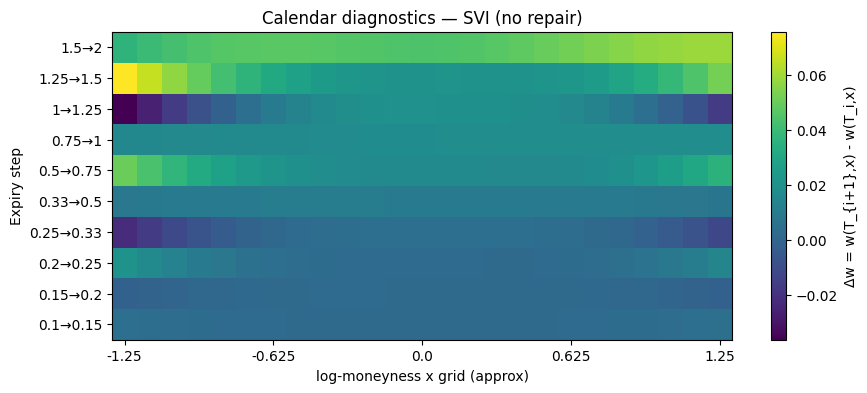

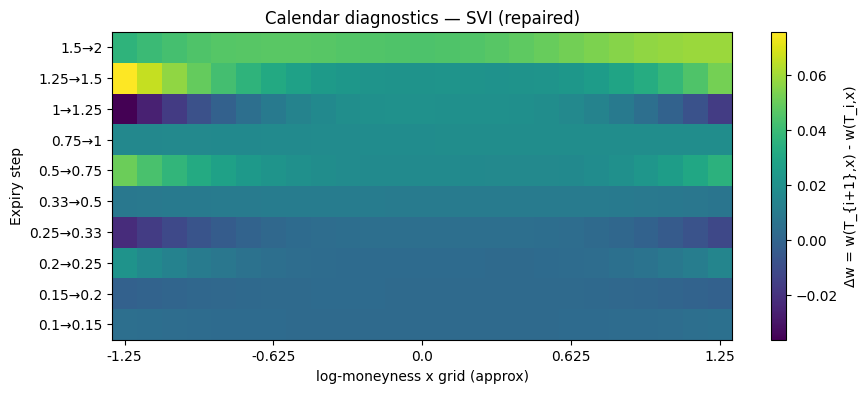

In [45]:
# Plot calendar diagnostics and violation structure if present
vs_plot.plot_calendar_heatmap_from_report(surface_grid, noarb_grid, title="Calendar diagnostics — raw grid surface")
vs_plot.plot_calendar_heatmap_from_report(surface_svi_norepair, noarb_svi_nr, title="Calendar diagnostics — SVI (no repair)")
vs_plot.plot_calendar_heatmap_from_report(surface_svi_repaired, noarb_svi_fx, title="Calendar diagnostics — SVI (repaired)")


=== First violation diagnostics: grid surface ===
No strike monotonicity violations found.


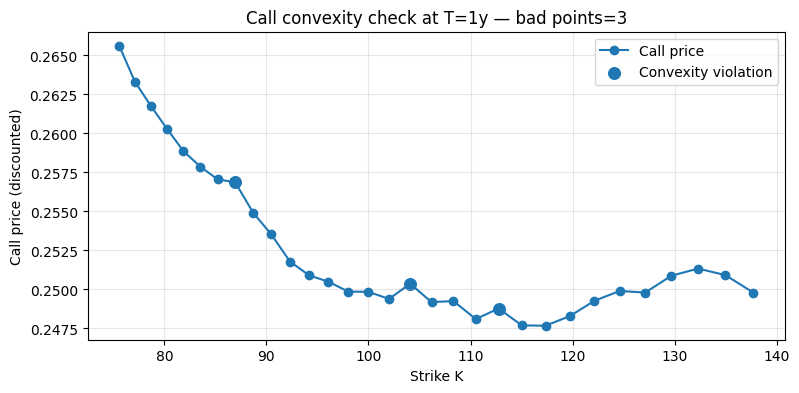

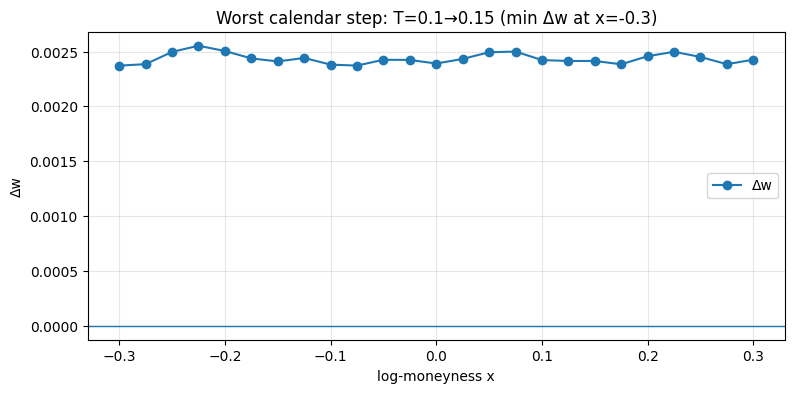

In [46]:
# Optional: inspect first detailed violations (very useful in interviews)
print("=== First violation diagnostics: grid surface ===")
vs_plot.plot_first_strike_monotonicity_violation(surface_grid, noarb_grid, forward=forward, df=df_curve)
vs_plot.plot_first_convexity_violation(surface_grid, noarb_grid, forward=forward, df=df_curve)
vs_plot.plot_worst_calendar_slice(surface_grid, noarb_grid)


## 3) SVI diagnostics (fit quality, residuals, butterfly proxy) + explicit repair showcase

This section makes your SVI work visible instead of just "hidden inside `from_svi`".


In [47]:
# Compare SVI fit quality tables (no-repair vs repaired)
svi_fit_nr = vs_svi.svi_fit_table(surface_svi_norepair)
svi_fit_fx = vs_svi.svi_fit_table(surface_svi_repaired)

compare_cols = [c for c in ["T", "diag_ok", "rmse_w", "mae_w", "min_g", "lee_ok", "butterfly_ok", "failure_reason"] if c in svi_fit_nr.columns]
svi_fit_compare = svi_fit_nr[compare_cols].merge(
    svi_fit_fx[compare_cols],
    on="T",
    how="outer",
    suffixes=("_nr", "_fx")
).sort_values("T")

show_table("SVI fit comparison (no-repair vs repaired)", svi_fit_compare, max_rows=12)

# Pick a focus expiry (worst RMSE on no-repair if available)
focus_T = None
if "rmse_w" in svi_fit_nr.columns and svi_fit_nr["rmse_w"].notna().any():
    focus_T = float(svi_fit_nr.sort_values("rmse_w", ascending=False).iloc[0]["T"])
else:
    focus_T = float(np.asarray(surface_svi_repaired.expiries, dtype=float)[len(surface_svi_repaired.expiries)//2])

print("Focus expiry for SVI plots:", focus_T)


### SVI fit comparison (no-repair vs repaired)

,T,diag_ok_nr,rmse_w_nr,mae_w_nr,min_g_nr,butterfly_ok_nr,failure_reason_nr,diag_ok_fx,rmse_w_fx,mae_w_fx,min_g_fx,butterfly_ok_fx,failure_reason_fx
0,0.10,True,0.000091,0.000072,0.004678,True,,True,0.000091,0.000072,0.004678,True,
1,0.15,True,0.000107,0.000091,0.012823,True,,True,0.000107,0.000091,0.012823,True,
2,0.20,True,0.000101,0.000081,0.046188,True,,True,0.000101,0.000081,0.046188,True,
3,0.25,False,0.000120,0.000093,-0.000665,False,g_below_floor,False,0.000120,0.000093,-0.000665,False,g_below_floor
4,0.33,True,0.000124,0.000102,0.126321,True,,True,0.000124,0.000102,0.126321,True,
5,0.50,True,0.000151,0.000129,0.213019,True,,True,0.000151,0.000129,0.213019,True,
6,0.75,False,0.000245,0.000207,-0.001042,False,g_below_floor,False,0.000245,0.000207,-0.001042,False,g_below_floor
7,1.00,False,0.000361,0.000288,-0.022571,False,g_below_floor,False,0.000361,0.000288,-0.022571,False,g_below_floor
8,1.25,True,0.000509,0.000427,0.347150,True,,True,0.000509,0.000427,0.347150,True,
9,1.50,False,0.000584,0.000493,-0.125388,False,g_below_floor,False,0.000584,0.000493,-0.125388,False,g_below_floor


Focus expiry for SVI plots: 2.0


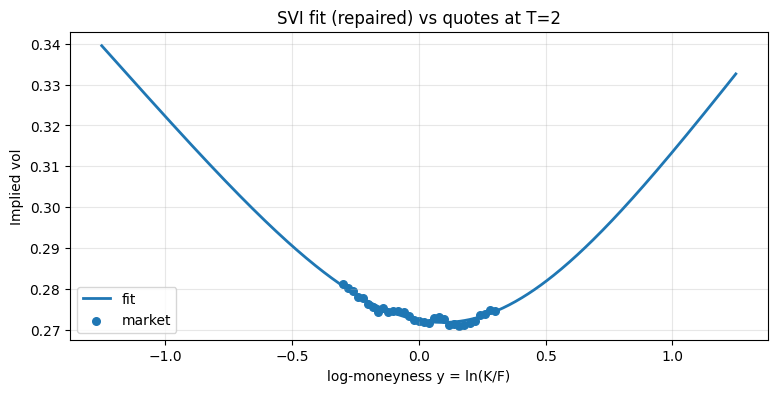

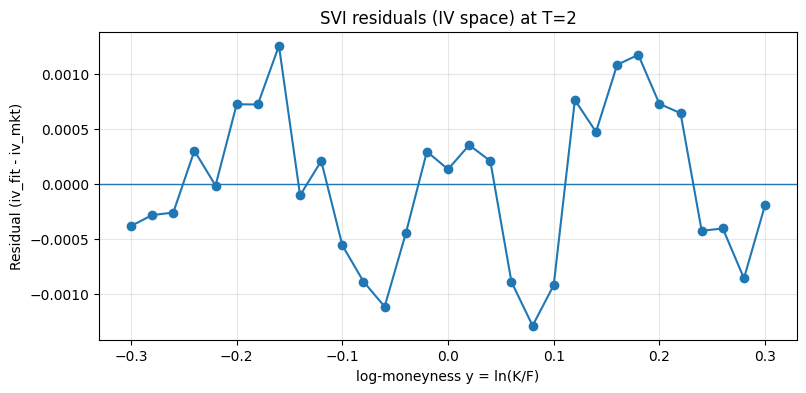

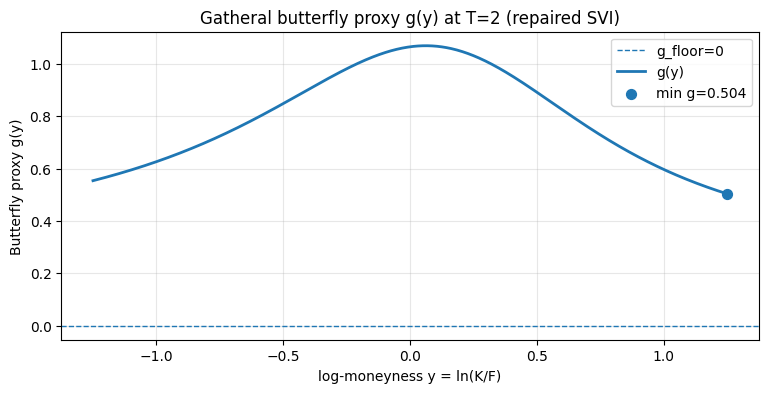

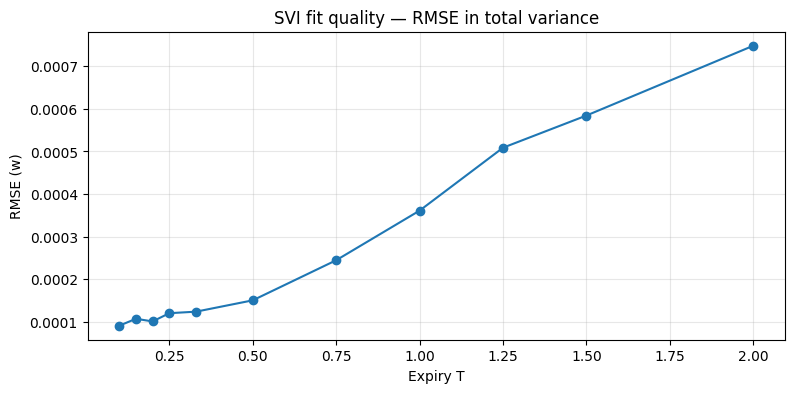

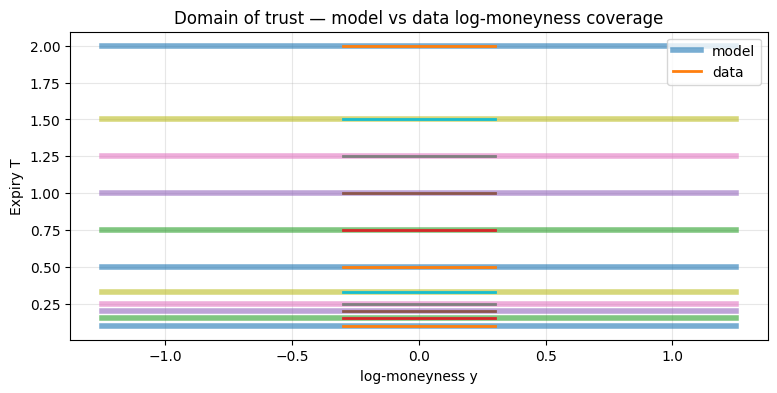

In [48]:
# Fit slice + residuals + butterfly proxy on the focus expiry
quotes_for_plots = quotes_df.rename(columns={"iv_obs": "iv"})[["T", "K", "iv"]]

vs_plot.plot_svi_fit_slice(
    surface_svi_repaired,
    T=focus_T,
    forward=forward,
    quotes_df=quotes_for_plots,
    kind="iv",
    title=f"SVI fit (repaired) vs quotes at T={focus_T:g}",
)

vs_plot.plot_svi_residuals(
    surface_svi_repaired,
    T=focus_T,
    forward=forward,
    quotes_df=quotes_for_plots,
    kind="iv",
    title=f"SVI residuals (IV space) at T={focus_T:g}",
)

vs_plot.plot_butterfly_proxy(
    surface_svi_repaired,
    T=focus_T,
    title=f"Gatheral butterfly proxy g(y) at T={focus_T:g} (repaired SVI)"
)

vs_plot.plot_svi_rmse_by_expiry(surface_svi_repaired)
vs_plot.plot_surface_domain_report(surface_svi_repaired, quotes_df=quotes_for_plots, forward=forward)


### Explicit bad-SVI demo metadata

,base_source,generator_source,good_ok,bad_ok,rho_abs,mode,b_base,b_bad,b_mult_eff,sigma_base,sigma_bad,sigma_mult_eff,b_wing_threshold,good_min_g,bad_min_g,bad_failure_reason,y_min,y_max,T
0,focus_slice_params,from_base_params,True,False,0.95,forced_wing,0.121875,1.046677,8.588093,0.881776,0.793598,0.9,1.026154,0.254534,-0.01036,"wing_limit_violation (gL_inf=0.25, gR_inf=-0.0...",-1.25,1.25,2.0


### Explicit SVI slice repair attempts

,method,ok,min_g,failure_reason,error
0,jw_optimal,True,-9.999993e-11,,


### Explicit SVI slice repair summary

,stage,ok,min_g,min_g_plot,argmin_plot,lee_ok,params,failure_reason
0,before_repair,False,-1.036017e-02,-0.112751,1.25,False,"SVIParams(a=0.04055164773264969, b=1.046676923...","wing_limit_violation (gL_inf=0.25, gR_inf=-0.0..."
1,after_repair,True,-9.999993e-11,0.071891,1.25,True,"SVIParams(a=-0.003440673113127707, b=0.8282524...",None


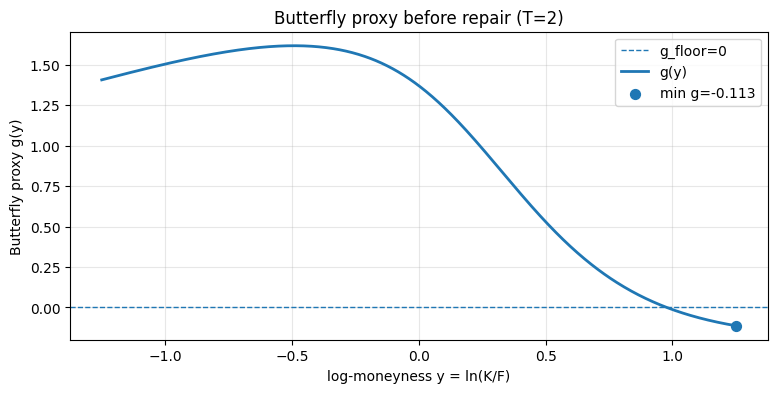

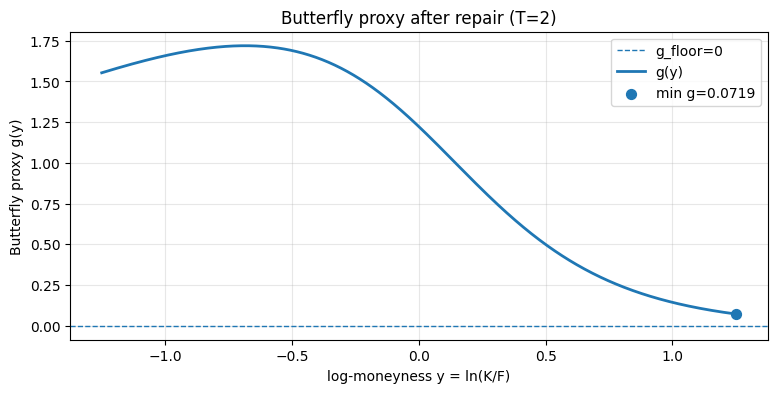

In [49]:

# --- Explicit "SVI fixing" demo on one slice (before/after) ---
explicit_repair_demo = run_explicit_svi_repair_demo(
    focus_T=float(focus_T),
    repaired_surface=surface_svi_repaired,
    w_floor=1e-12,
    g_floor=0.0,
    plot_grid_size=801,
    y_obj_size=101,
    y_penalty_size=301,
    repair_scan_size=101,
    repair_bisect_steps=50,
)

show_table(
    "Explicit bad-SVI demo metadata",
    explicit_repair_demo.metadata,
    max_rows=20,
)
show_table(
    "Explicit SVI slice repair attempts",
    explicit_repair_demo.repair_attempts,
    max_rows=10,
)
show_table(
    "Explicit SVI slice repair summary",
    explicit_repair_demo.summary,
    max_rows=10,
)

vs_plot.plot_butterfly_proxy(
    explicit_repair_demo.smile_pre_plot,
    title=f"Butterfly proxy before repair (T={explicit_repair_demo.smile_pre_plot.T:g})",
)
vs_plot.plot_butterfly_proxy(
    explicit_repair_demo.smile_post_plot,
    title=f"Butterfly proxy after repair (T={explicit_repair_demo.smile_post_plot.T:g})",
)


### GJ (2013) Example 5.1: computed vs paper

,quantity,computed,paper
0,JW.v,0.017426,0.017426
1,JW.psi,-0.175211,-0.175211
2,JW.p,0.699738,0.699738
3,JW.c,1.316798,1.316798
4,JW.v_tilde,0.011625,0.011625
5,Section 5.1 target c0,0.349316,0.349316
6,Section 5.1 target vtilde0,0.015482,0.015482
7,Projected c0 (actual),0.349316,0.349316
8,Projected vtilde0 (actual),0.015482,0.015482
9,Optimal c*,1.064430,0.856476


### GJ (2013) Example 5.1: butterfly checks

,stage,ok,min_g,failure_reason
0,orig,False,-3.286357e-02,g_below_floor
1,projected,True,2.534913e-01,None
2,optimal,True,-9.434344e-11,None


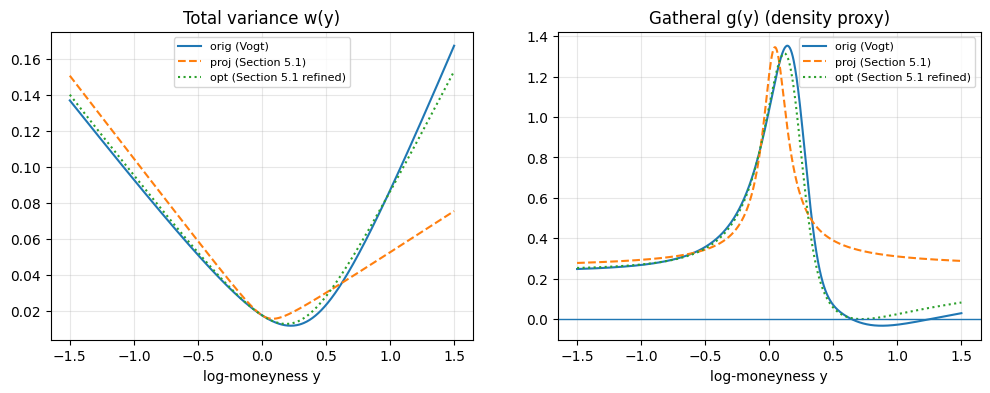

In [50]:

# --- Gatheral–Jacquier (2013) Example 5.1: smile repair sanity check ---
# This now delegates the paper-example orchestration to the library diagnostics helper.

gj51 = run_gj_example51_repair_sanity_check(
    T=1.0,
    y_domain_hint=(-1.5, 1.5),
    w_floor=1e-12,
    y_obj=np.linspace(-1.5, 1.5, 301),
    y_penalty=np.linspace(-1.5, 1.5, 1201),
    y_plot=np.linspace(-1.5, 1.5, 801),
    lambda_price=1.0,
    lambda_g=1e7,
    g_floor=0.0,
    g_scale=0.02,
    lambda_wfloor=0.0,
    max_nfev=2000,
)

show_table(
    "GJ (2013) Example 5.1: computed vs paper",
    gj_example51_comparison_table(gj51),
    max_rows=20,
)
show_table(
    "GJ (2013) Example 5.1: butterfly checks",
    gj_example51_check_table(gj51),
    max_rows=10,
)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(gj51.y_plot, gj51.w_raw, label="orig (Vogt)")
ax[0].plot(gj51.y_plot, gj51.w_projected, linestyle="--", label="proj (Section 5.1)")
ax[0].plot(gj51.y_plot, gj51.w_optimal, linestyle=":", label="opt (Section 5.1 refined)")
ax[0].set_title("Total variance w(y)")
ax[0].set_xlabel("log-moneyness y")
ax[0].grid(True, alpha=0.3)
ax[0].legend(fontsize=8)

ax[1].plot(gj51.y_plot, gj51.g_raw, label="orig (Vogt)")
ax[1].plot(gj51.y_plot, gj51.g_projected, linestyle="--", label="proj (Section 5.1)")
ax[1].plot(gj51.y_plot, gj51.g_optimal, linestyle=":", label="opt (Section 5.1 refined)")
ax[1].axhline(0.0, linewidth=1.0)
ax[1].set_title("Gatheral g(y) (density proxy)")
ax[1].set_xlabel("log-moneyness y")
ax[1].grid(True, alpha=0.3)
ax[1].legend(fontsize=8)

plt.show()


## 4) No-arb interpolation choice demo (`no_arb` vs `linear_w`) and time-slice diagnostics

Use this to explain why you expose **two interpolation modes**:
- `no_arb`: presentation / quote interpolation with no-arb price blending narrative
- `linear_w`: differentiable total-variance interpolation for local-vol derivative calculations


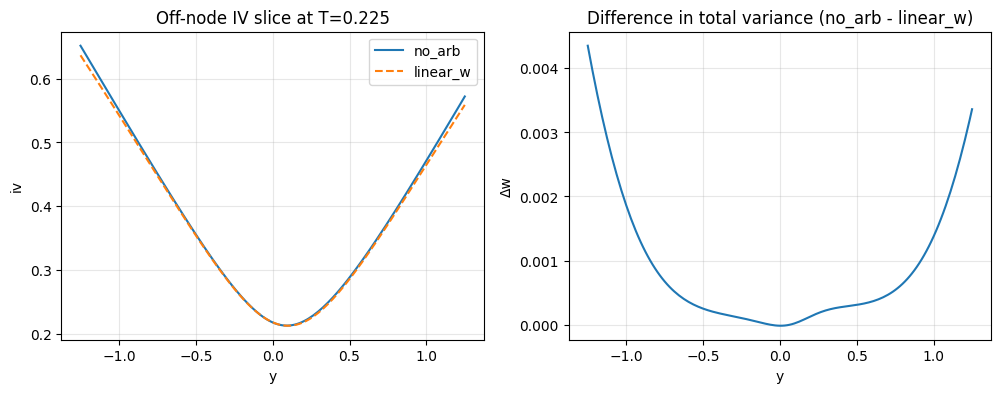

In [51]:
# Compare off-node slices under the two interpolation modes at one intermediate maturity
expiries = np.asarray(surface_svi_repaired.expiries, dtype=float)
T_mid = float(0.5 * (expiries[2] + expiries[3]))  # between two nodes
s_noarb = surface_svi_repaired.slice(T_mid, method="no_arb")
s_linw = surface_svi_repaired.slice(T_mid, method="linear_w")

yq = np.linspace(max(float(s_noarb.y_min), float(s_linw.y_min)),
                 min(float(s_noarb.y_max), float(s_linw.y_max)),
                 161)

iv_noarb = np.asarray(s_noarb.iv_at(yq), dtype=float)
iv_linw = np.asarray(s_linw.iv_at(yq), dtype=float)
w_noarb = np.asarray(s_noarb.w_at(yq), dtype=float)
w_linw = np.asarray(s_linw.w_at(yq), dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(yq, iv_noarb, label="no_arb")
axes[0].plot(yq, iv_linw, label="linear_w", linestyle="--")
axes[0].set_title(f"Off-node IV slice at T={T_mid:g}")
axes[0].set_xlabel("y")
axes[0].set_ylabel("iv")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(yq, w_noarb - w_linw)
axes[1].set_title("Difference in total variance (no_arb - linear_w)")
axes[1].set_xlabel("y")
axes[1].set_ylabel("Δw")
axes[1].grid(True, alpha=0.3)

plt.show()


## 5) Local vol from the repaired SVI surface + diagnostics

This is where your **diagnostics-first local-vol engineering** should shine:
- invalid masks and reason codes
- denominator heatmaps
- "where the surface is unreliable" tables


In [ ]:
localvol = LocalVolSurface.from_implied(
    surface_svi_repaired,
    forward=forward,
    discount=df_curve,
 )

lv_rep = vs_localvol.localvol_grid_diagnostics(
    localvol,
    expiries=LV_DIAG_EXPIRIES,
    y_grid=LV_DIAG_YGRID,
    eps_w=1e-12,
    eps_denom=1e-12,
    top_n=15,
 )

show_table("Local-vol diagnostics summary", pd.DataFrame([vs_localvol.localvol_summary(lv_rep)]), max_rows=10)


reason_counts_df = pd.DataFrame(
    [{"reason": k, "count": v} for k, v in lv_rep.reason_counts.items()]
 )
if not reason_counts_df.empty:
    reason_counts_df = reason_counts_df.sort_values("count", ascending=False)
show_table("Invalid reason counts", reason_counts_df, max_rows=15)

show_table("Worst denominator points / suspect locations", lv_rep.worst_points, max_rows=12)


<string>:6: FutureWarning: LocalVolSurface is currently derived from per-expiry SVI slices with piecewise-linear time interpolation in total variance. This is demo-grade and can be numerically unstable (e.g., banding from discontinuous w_T). It will be replaced by a time-consistent SSVI/eSSVI implementation in a future version.


### Local-vol diagnostics summary

,invalid_count,invalid_frac,sigma_min,sigma_median,sigma_max,denom_abs_min
0,0,0.0,0.21036,0.285047,0.396889,0.310395


### Invalid reason counts

""


### Worst denominator points / suspect locations

,rank,T,y,K,denom,local_var,sigma,invalid,reasons
0,1,0.12,-0.30,74.259832,0.310395,0.157521,0.396889,False,
1,2,0.12,-0.29,75.006156,0.324215,0.150728,0.388237,False,
2,3,0.12,-0.28,75.759980,0.338816,0.144166,0.379692,False,
3,4,0.12,0.30,135.310236,0.345415,0.140971,0.375461,False,
4,5,0.12,-0.27,76.521381,0.354236,0.137834,0.371261,False,
5,6,0.12,-0.26,77.290433,0.370513,0.131733,0.362950,False,
6,7,0.12,0.29,133.963877,0.373077,0.130462,0.361196,False,
7,8,0.12,-0.25,78.067215,0.387684,0.125860,0.354768,False,
8,9,0.12,0.28,132.630914,0.402549,0.120867,0.347660,False,
9,10,0.12,-0.24,78.851804,0.405783,0.120216,0.346721,False,


_Showing first 12 of 15 rows. Set `SHOW_VERBOSE_TABLES = True` for full tables._

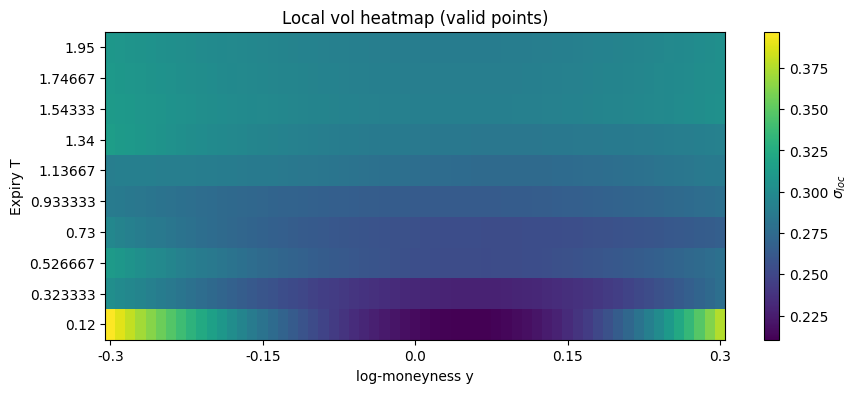

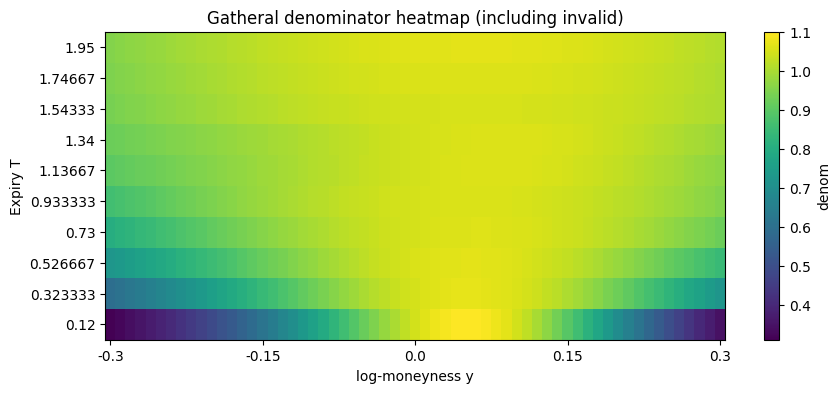

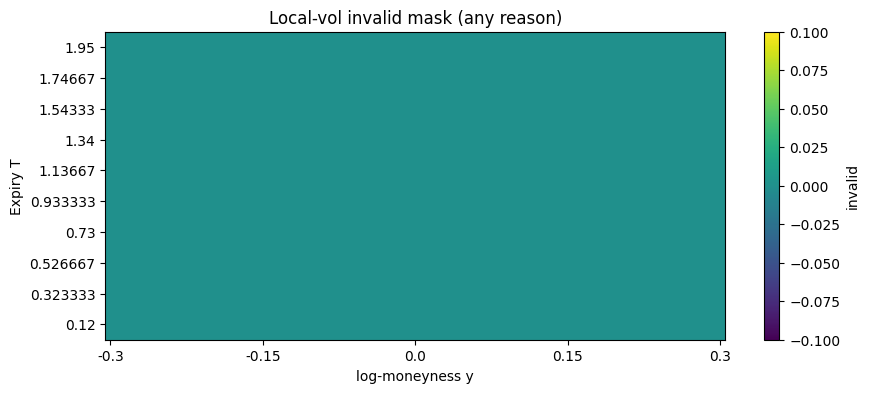

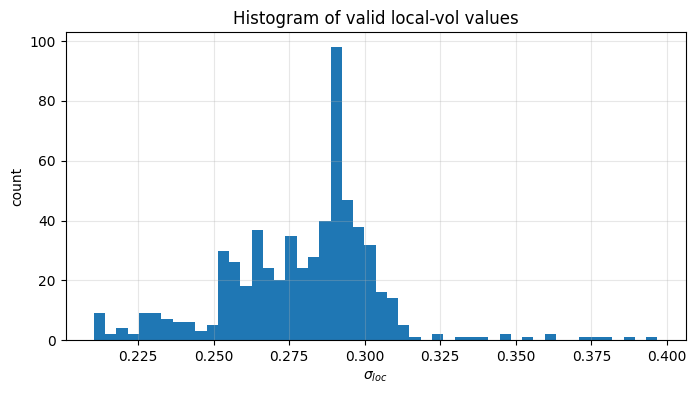

In [53]:
vs_plot.plot_localvol_heatmap(lv_rep, kind="sigma", title="Local vol heatmap (valid points)")
vs_plot.plot_localvol_heatmap(lv_rep, kind="denom", mask_invalid=False, title="Gatheral denominator heatmap (including invalid)")
vs_plot.plot_localvol_invalid_mask(lv_rep, title="Local-vol invalid mask (any reason)")
vs_plot.plot_localvol_histogram(lv_rep, title="Histogram of valid local-vol values")


### Gatheral vs Dupire local-vol comparison summary

,n_total,n_compared,compared_frac,gatheral_invalid_frac,dupire_invalid_frac,union_invalid_frac,diff_sigma_rmse,diff_sigma_mae,diff_sigma_max_abs
0,341,261,0.765396,0.0,0.234604,0.234604,0.004507,0.003787,0.016202


### Worst local-vol disagreements (Dupire - Gatheral)

,rank,T,K,y,sigma_gatheral,sigma_dupire,diff_sigma,denom_gatheral,denom_dupire
0,1,0.15,128.166667,0.245161,0.282858,0.299060,0.016202,0.607653,5.784440
1,2,1.25,76.833333,-0.288532,0.288655,0.301095,0.012440,0.920641,65.987121
2,3,0.15,126.333333,0.230754,0.272013,0.283680,0.011666,0.656979,8.998667
3,4,1.25,78.666667,-0.264951,0.289371,0.299677,0.010306,0.929694,72.620039
4,5,0.50,98.833333,-0.021735,0.240617,0.249318,0.008701,1.042263,246.845523
5,6,0.50,100.666667,-0.003355,0.239240,0.247913,0.008673,1.053241,255.049032
6,7,1.25,80.500000,-0.241913,0.289699,0.298308,0.008609,0.938822,79.352685
7,8,0.50,97.000000,-0.040459,0.242385,0.250968,0.008582,1.028379,234.992907
8,9,0.50,102.500000,0.014693,0.238245,0.246741,0.008495,1.061243,259.303132
9,10,0.50,95.166667,-0.059540,0.244553,0.252878,0.008325,1.011711,219.990686


### Invalid reason counts (Gatheral)

""
0


### Invalid reason counts (Dupire)

,LOCALVAR_NEGATIVE,TRIM_T,TRIM_K
0,3,62,22


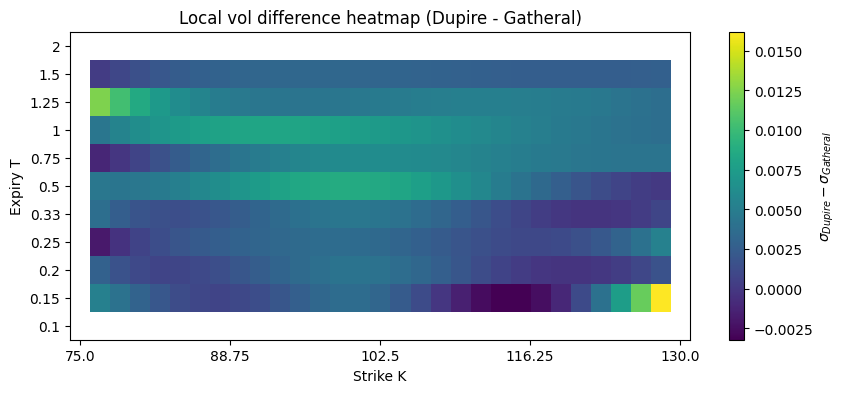

In [54]:
# Optional: compare Gatheral-from-w local vol vs Dupire-from-call-grid on a shared strike grid
if RUN_DUPIRE_VS_GATHERAL_COMPARE:
    mkt = MarketData(spot=SYNTH_CFG["spot"], rate=SYNTH_CFG["r"], dividend_yield=SYNTH_CFG["q"])
    lv_cmp = vs_localvol.localvol_compare_gatheral_vs_dupire(
        localvol,
        expiries=SHARED_EXPIRIES,
        strikes=SHARED_STRIKES,
        market=mkt,
        price_convention="discounted",
        strike_coordinate="logK",
        trim_t=1,
        trim_k=1,
        top_n=12,
    )

    show_table("Gatheral vs Dupire local-vol comparison summary", pd.DataFrame([lv_cmp.summary]), max_rows=10)

    show_table("Worst local-vol disagreements (Dupire - Gatheral)", lv_cmp.worst_diffs, max_rows=12)

    show_table("Invalid reason counts (Gatheral)", pd.DataFrame([lv_cmp.gatheral_reason_counts]), max_rows=10)

    show_table("Invalid reason counts (Dupire)", pd.DataFrame([lv_cmp.dupire_reason_counts]), max_rows=10)

    vs_plot.plot_localvol_method_diff(lv_cmp, kind="sigma", title="Local vol difference heatmap (Dupire - Gatheral)")


## 6) PDE diagnostics baseline (constant-vol digital) — convergence + stability story

This is your numerics-credibility segment. It is intentionally **simple but sensitive** (digital payoff).


### Digital PDE sweep (OK runs)

,contract,kind,payout,tau,spot,strike,sigma,r,q,sweep,...,pde,err,abs_err,rel_err,x0,feasible,within_budget,feasible_and_within_budget,score,domain_n_sigma
0,digital,call,1.0,1.0,100.0,100.0,0.22,0.02,0.0,NxNt,...,0.482637,0.000003,0.000003,0.000006,4.60517,True,True,True,99.0193,4.0
1,digital,call,1.0,1.0,100.0,100.0,0.22,0.02,0.0,NxNt,...,0.482637,0.000003,0.000003,0.000006,4.60517,True,True,True,171.3500,4.0
2,digital,call,1.0,1.0,100.0,100.0,0.22,0.02,0.0,NxNt,...,0.482637,0.000003,0.000003,0.000006,4.60517,True,False,False,NaN,4.0
3,digital,call,1.0,1.0,100.0,100.0,0.22,0.02,0.0,NxNt,...,0.482637,0.000002,0.000002,0.000005,4.60517,True,True,True,107.0600,4.0
4,digital,call,1.0,1.0,100.0,100.0,0.22,0.02,0.0,NxNt,...,0.482637,0.000002,0.000002,0.000005,4.60517,True,True,True,218.2947,4.0
5,digital,call,1.0,1.0,100.0,100.0,0.22,0.02,0.0,NxNt,...,0.482637,0.000002,0.000002,0.000005,4.60517,True,False,False,NaN,4.0
6,digital,call,1.0,1.0,100.0,100.0,0.22,0.02,0.0,NxNt,...,0.482636,0.000001,0.000001,0.000003,4.60517,True,True,True,140.1620,4.0
7,digital,call,1.0,1.0,100.0,100.0,0.22,0.02,0.0,NxNt,...,0.482636,0.000001,0.000001,0.000003,4.60517,True,True,True,241.0405,4.0
8,digital,call,1.0,1.0,100.0,100.0,0.22,0.02,0.0,NxNt,...,0.482636,0.000001,0.000001,0.000003,4.60517,True,False,False,NaN,4.0
9,digital,call,1.0,1.0,100.0,100.0,0.22,0.02,0.0,NxNt,...,0.482637,0.000002,0.000002,0.000004,4.60517,True,True,True,93.1859,5.0


_Showing first 12 of 72 rows. Set `SHOW_VERBOSE_TABLES = True` for full tables._

### Grouped summary (mean error/runtime by method/advection/grid)

,method,advection,Nx,Nt,n,abs_err_mean,abs_err_max,runtime_ms_mean,feasible_rate
0,rannacher,upwind,201,101,2,0.000001,0.000001,146.37920,1.0
1,rannacher,upwind,201,201,2,0.000001,0.000001,308.81960,0.0
2,rannacher,upwind,201,401,2,0.000001,0.000001,522.35405,0.0
3,cn,upwind,201,401,2,0.000001,0.000001,520.01775,0.0
4,cn,upwind,201,201,2,0.000001,0.000001,271.15220,0.0
5,cn,upwind,201,101,2,0.000001,0.000002,162.46640,1.0
6,cn,central,201,101,2,0.000002,0.000002,139.99040,1.0
7,cn,central,201,201,2,0.000002,0.000002,240.97665,1.0
8,cn,central,201,401,2,0.000002,0.000002,519.39790,0.0
9,rannacher,central,201,401,2,0.000002,0.000002,526.81520,0.0


_Showing first 12 of 36 rows. Set `SHOW_VERBOSE_TABLES = True` for full tables._

### Pareto frontier (runtime vs abs error)

,contract,kind,payout,tau,spot,strike,sigma,r,q,sweep,...,pde,err,abs_err,rel_err,x0,feasible,within_budget,feasible_and_within_budget,score,domain_n_sigma
0,digital,call,1.0,1.0,100.0,100.0,0.22,0.02,0.0,NxNt,...,0.482637,0.000003,0.000003,0.000006,4.60517,True,True,True,85.5840,4.0
1,digital,call,1.0,1.0,100.0,100.0,0.22,0.02,0.0,NxNt,...,0.482637,0.000002,0.000002,0.000004,4.60517,True,True,True,93.1859,5.0
2,digital,call,1.0,1.0,100.0,100.0,0.22,0.02,0.0,NxNt,...,0.482633,-0.000002,0.000002,0.000003,4.60517,True,True,True,116.2568,4.0
3,digital,call,1.0,1.0,100.0,100.0,0.22,0.02,0.0,NxNt,...,0.482633,-0.000001,0.000001,0.000003,4.60517,True,True,True,136.8016,5.0
4,digital,call,1.0,1.0,100.0,100.0,0.22,0.02,0.0,NxNt,...,0.482633,-0.000001,0.000001,0.000003,4.60517,True,True,True,155.9568,4.0


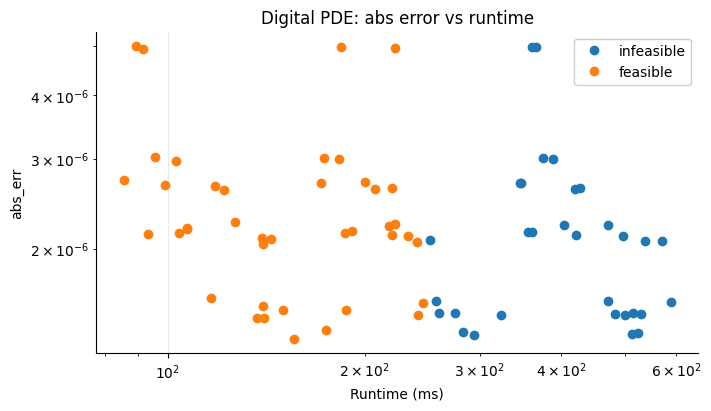

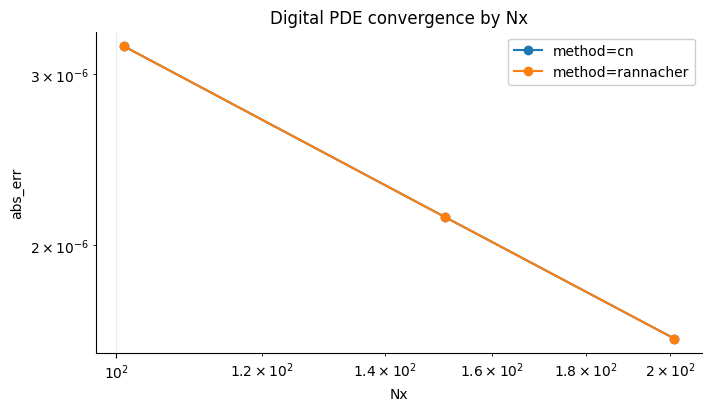

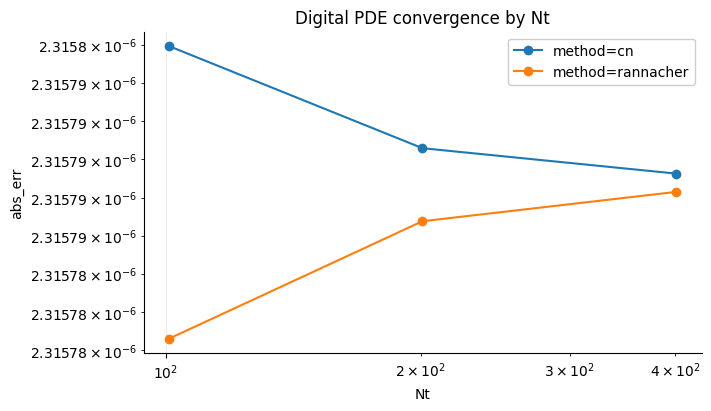

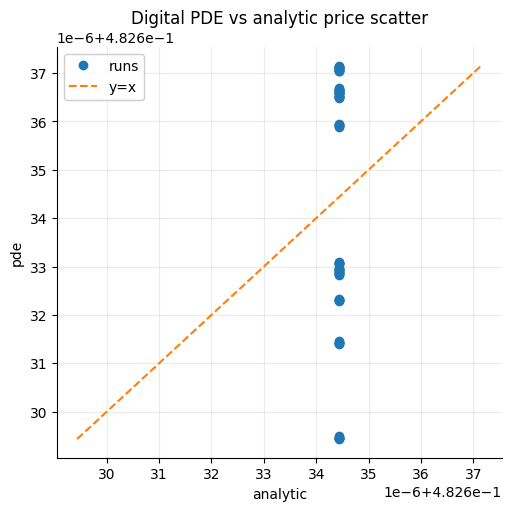

In [55]:

if RUN_DIGITAL_PDE_BASELINE:
    sigma_bs = 0.22
    p_dig = PricingInputs(
        spec=DigitalSpec(kind=OptionType.CALL, strike=100.0, expiry=1.0, payout=1.0),
        market=MarketData(spot=100.0, rate=0.02, dividend_yield=0.00),
        sigma=sigma_bs,
    )

    digital_baseline = run_demo_baseline_sweep(
        p_dig,
        methods=("cn", "rannacher"),
        advections=("central", "upwind"),
        n_sigmas=(4.0, 5.0),
        Nx_list=(101, 151, 201),
        Nt_list=(101, 201, 401),
        coord=Coord.LOG_S,
        spacing="uniform",
        ic_remedy="cell_avg",
        tol_abs=5e-4,
        tol_rel=5e-3,
        budget_ms=250.0,
    )

    show_table("Digital PDE sweep (OK runs)", digital_baseline.ok, max_rows=12)

    if not digital_baseline.errors.empty:
        show_table("Failed runs (if any)", digital_baseline.errors, max_rows=12)

    show_table(
        "Grouped summary (mean error/runtime by method/advection/grid)",
        digital_baseline.grouped,
        max_rows=12,
    )
    show_table(
        "Pareto frontier (runtime vs abs error)",
        digital_baseline.frontier,
        max_rows=12,
    )

    pde_plot_error_vs_runtime(
        digital_baseline.ok,
        title="Digital PDE: abs error vs runtime",
    )
    pde_plot_convergence(
        digital_baseline.ok,
        x_col="Nx",
        y_col="abs_err",
        group_col="method",
        title="Digital PDE convergence by Nx",
    )
    pde_plot_convergence(
        digital_baseline.ok,
        x_col="Nt",
        y_col="abs_err",
        group_col="method",
        title="Digital PDE convergence by Nt",
    )
    pde_plot_price_scatter(
        digital_baseline.ok,
        x_col="analytic",
        y_col="pde",
        title="Digital PDE vs analytic price scatter",
    )


## 7) End-to-end local-vol PDE repricing checks (vanillas)

Here the story is:
1. Use the repaired SVI surface as the "market" implied surface
2. Build local vol from it
3. PDE-price vanillas under local vol
4. Compare back to target prices / implied vols (repricing consistency)


### Local-vol PDE repricing table

,T,K,target_iv,target_price,pde_price,abs_price_error,pde_iv,abs_iv_error_bp,iv_ok,iv_error,runtime_ms,Nx,Nt
0,0.1,78.666667,0.313077,21.511381,21.497050,0.014331,0.276356,367.206342,True,,704.6032,201,401
1,0.1,82.333333,0.288996,17.877885,17.852980,0.024905,0.261268,277.287037,True,,759.5765,201,401
2,0.1,86.000000,0.267381,14.281507,14.244358,0.037149,0.249056,183.242756,True,,669.9596,201,401
3,0.1,89.666667,0.248396,10.776502,10.734273,0.042229,0.238362,100.337291,True,,650.8779,201,401
4,0.1,93.333333,0.232227,7.481766,7.459998,0.021768,0.229356,28.713163,True,,650.6339,201,401
5,0.1,97.000000,0.219060,4.608806,4.643508,0.034702,0.222178,31.171935,True,,654.7316,201,401
6,0.1,100.666667,0.209046,2.416666,2.516623,0.099957,0.216974,79.281524,True,,726.3005,201,401
7,0.1,104.333333,0.202264,1.044498,1.168182,0.123683,0.213875,116.108572,True,,649.0146,201,401
8,0.1,108.000000,0.198686,0.371058,0.466800,0.095743,0.212892,142.058143,True,,682.7920,201,401
9,0.1,111.666667,0.198158,0.112627,0.165742,0.053115,0.214050,158.919360,True,,681.5175,201,401


_Showing first 12 of 154 rows. Set `SHOW_VERBOSE_TABLES = True` for full tables._

### Repricing summary

,n_options,mean_abs_price_error,max_abs_price_error,mean_abs_iv_error_bp,max_abs_iv_error_bp,mean_runtime_ms,total_runtime_ms,Nx,Nt
0,154,0.144172,0.66491,80.247441,367.206342,681.094142,105758.548,201,401


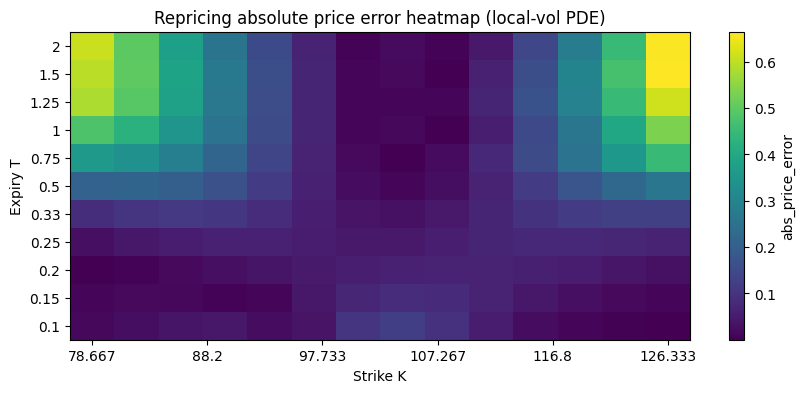

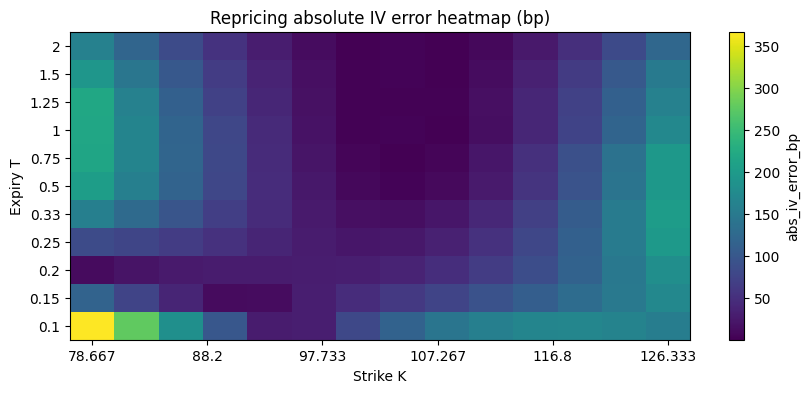

In [56]:
if RUN_LOCALVOL_REPRICING:
    # Use a moderate grid for a runtime-friendly showcase repricing heatmap
    repricing_res = localvol_pde_repricing_grid(
        lv=localvol,
        market=MarketData(
            spot=SYNTH_CFG["spot"],
            rate=SYNTH_CFG["r"],
            dividend_yield=SYNTH_CFG["q"],
        ),
        strikes=SHARED_STRIKES[2:-2:2],
        expiries=SHARED_EXPIRIES,
        Nx=201,
        Nt=401,
        solver_cfg=LV_PDE_SOLVER_CFG,
        kind=OptionType.CALL,
        target="black76_from_implied",
        compute_implied_vol=True,
    )

    show_table("Local-vol PDE repricing table", repricing_res.grid, max_rows=12)
    show_table("Repricing summary", repricing_res.summary, max_rows=10)

    plot_repricing_heatmap(
        repricing_res.grid,
        value_col="abs_price_error",
        title="Repricing absolute price error heatmap (local-vol PDE)",
    )
    plot_repricing_heatmap(
        repricing_res.grid,
        value_col="abs_iv_error_bp",
        title="Repricing absolute IV error heatmap (bp)",
    )

### Local-vol PDE convergence sweep (single option)

,Nx,Nt,grid_points,pde_price,target_price,abs_error,runtime_ms
0,101,201,20301,9.923128,9.929445,0.006317,243.0952
1,151,301,45451,9.925474,9.929445,0.003971,393.8521
2,201,401,80601,9.925650,9.929445,0.003794,602.3385
3,251,501,125751,9.925901,9.929445,0.003543,822.2361


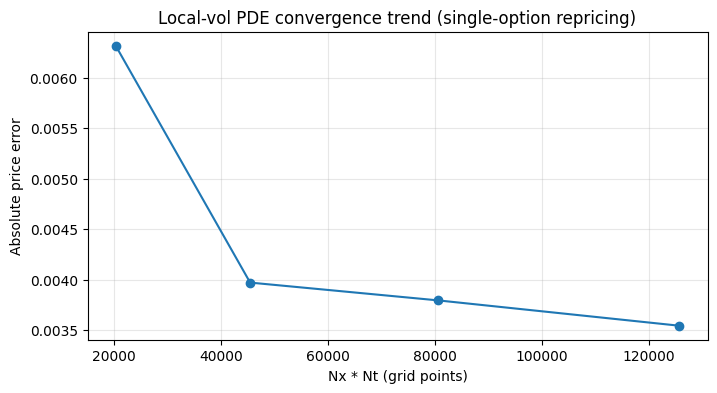

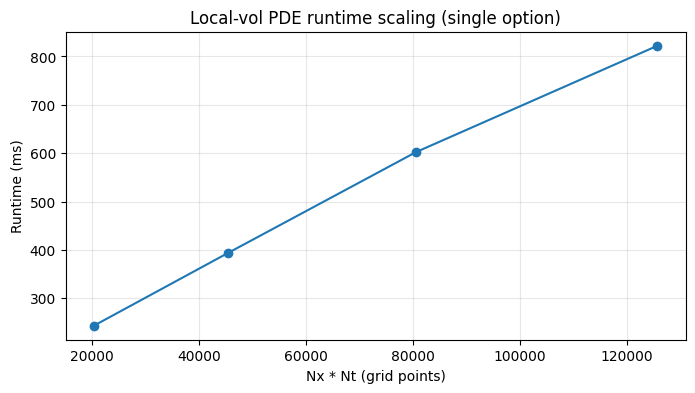

In [57]:

if RUN_LOCALVOL_CONVERGENCE_SWEEP:
    # Convergence on a single representative option (ATM-forward 1Y call)
    T0 = 1.0
    K0 = float(forward(T0))
    mkt = MarketData(
        spot=SYNTH_CFG["spot"],
        rate=SYNTH_CFG["r"],
        dividend_yield=SYNTH_CFG["q"],
    )

    conv_res = localvol_pde_single_option_convergence_sweep(
        lv=localvol,
        market=mkt,
        strike=K0,
        expiry=T0,
        grids=LV_SWEEP_GRIDS,
        solver_cfg=LV_PDE_SOLVER_CFG,
        kind=OptionType.CALL,
    )
    conv_df = conv_res.grid
    show_table("Local-vol PDE convergence sweep (single option)", conv_df, max_rows=12)

    plt.figure(figsize=(8, 4))
    plt.plot(conv_df["grid_points"], conv_df["abs_error"], marker="o")
    plt.xlabel("Nx * Nt (grid points)")
    plt.ylabel("Absolute price error")
    plt.title("Local-vol PDE convergence trend (single-option repricing)")
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(conv_df["grid_points"], conv_df["runtime_ms"], marker="o")
    plt.xlabel("Nx * Nt (grid points)")
    plt.ylabel("Runtime (ms)")
    plt.title("Local-vol PDE runtime scaling (single option)")
    plt.grid(True, alpha=0.3)
    plt.show()


## 8) Demo wrap-up / talking points (for presentation)

### What this demonstrates clearly
- **Surface diagnostics first**: raw grid vs SVI surfaces, and where no-arb checks fail/pass.
- **SVI craftsmanship**: fit quality tables, residuals, butterfly proxy, and explicit repair demo.
- **Interpolation intent**: `no_arb` for smile interpolation narrative vs `linear_w` for differentiability / Dupire.
- **Local-vol guardrails**: denominator heatmaps, invalid masks, and reason-coded failures.
- **PDE engineering**: convergence + runtime plots (digital baseline) and end-to-end repricing consistency under local vol.

### What to say explicitly in the demo
- "I don't just compute local vol; I show **where it is trustworthy** and **why**."
- "I expose diagnostics because Dupire/local-vol is derivative-sensitive and numerically fragile."
- "The no-arb and SVI repair paths are not marketing claims — the notebook shows the checks."

### Optional polish before interviews
- Export a compact JSON diagnostics artifact per run (using `SurfaceDiagnosticsReport.to_json()`).
- Add a fast mode and full mode toggle for deterministic demo timing.
- Save selected plots to `artifacts/` with timestamps for CI regression comparisons.
